# Taller 3 - Agrupamiento k-means y jerárquico aglomerativo

## Desarrollo del método AJA

### Integrantes del grupo:

- Carlos Manuel Carvajales Castrillo
- Mateo Ruiz Mendoza

Este Notebook tiene como objetivo mostrar el desarrollo del taller aplicando el método **AJA** para el dataset **Drug Compsution**.

In [1]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [7]:
%pip list

Package                   Version
------------------------- -----------
anyio                     4.12.1
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.2.0
attrs                     25.4.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.5
comm                      0.2.3
contourpy                 1.3.3
cryptography              46.0.5
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
defusedxml                0.7.1
executing                 2.2.1
fastjsonschema            2.21.2
fonttools                 4.62.1
fqdn                      1.5.1
greenlet                  3.3.2
h11                       0.16.0
httpcore                  1.0.9
httpx                     0.28.1
idna           

In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
drug_consumption_quantified = fetch_ucirepo(id=373) 
  
# data (as pandas dataframes) 
X = drug_consumption_quantified.data.features 
y = drug_consumption_quantified.data.targets 
  
# metadata 
print(drug_consumption_quantified.metadata) 
  
# variable information 
print(drug_consumption_quantified.variables) 


{'uci_id': 373, 'name': 'Drug Consumption (Quantified)', 'repository_url': 'https://archive.ics.uci.edu/dataset/373/drug+consumption+quantified', 'data_url': 'https://archive.ics.uci.edu/static/public/373/data.csv', 'abstract': 'Classify type of drug consumer by personality data', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1885, 'num_features': 12, 'feature_types': ['Real'], 'demographics': ['Age', 'Gender', 'Education Level', 'Nationality', 'Ethnicity'], 'target_col': ['alcohol', 'amphet', 'amyl', 'benzos', 'caff', 'cannabis', 'choc', 'coke', 'crack', 'ecstasy', 'heroin', 'ketamine', 'legalh', 'lsd', 'meth', 'mushrooms', 'nicotine', 'semer', 'vsa'], 'index_col': ['id'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Fri Mar 08 2024', 'dataset_doi': '10.24432/C5TC7S', 'creators': ['Elaine Fehrman', 'Vincent Egan', 'Evgeny Mirkes'], 'intro_paper': {'ID': 413, 

In [5]:
display(X)
display(y)

,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,impuslive,ss
0,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,-0.21712,-1.18084
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,-0.71126,-0.21575
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,-1.37983,0.40148
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,-1.37983,-1.18084
4,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,-0.21712,-0.21575
...,...,...,...,...,...,...,...,...,...,...,...,...
1880,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,-1.19430,1.74091,1.88511,0.76096,-1.13788,0.88113,1.92173
1881,-0.95197,-0.48246,-0.61113,-0.57009,-0.31685,-0.24649,1.74091,0.58331,0.76096,-1.51840,0.88113,0.76540
1882,-0.07854,0.48246,0.45468,-0.57009,-0.31685,1.13281,-1.37639,-1.27553,-1.77200,-1.38502,0.52975,-0.52593
1883,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,0.91093,-1.92173,0.29338,-1.62090,-2.57309,1.29221,1.22470


,alcohol,amphet,amyl,benzos,caff,cannabis,choc,coke,crack,ecstasy,heroin,ketamine,legalh,lsd,meth,mushrooms,nicotine,semer,vsa
0,CL5,CL2,CL0,CL2,CL6,CL0,CL5,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,CL5,CL2,CL2,CL0,CL6,CL4,CL6,CL3,CL0,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,CL6,CL0,CL0,CL0,CL6,CL3,CL4,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,CL4,CL0,CL0,CL3,CL5,CL2,CL4,CL2,CL0,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,CL4,CL1,CL1,CL0,CL6,CL3,CL6,CL0,CL0,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880,CL5,CL0,CL0,CL0,CL4,CL5,CL4,CL0,CL0,CL0,CL0,CL0,CL3,CL3,CL0,CL0,CL0,CL0,CL5
1881,CL5,CL0,CL0,CL0,CL5,CL3,CL4,CL0,CL0,CL2,CL0,CL0,CL3,CL5,CL4,CL4,CL5,CL0,CL0
1882,CL4,CL6,CL5,CL5,CL6,CL6,CL6,CL4,CL0,CL4,CL0,CL2,CL0,CL2,CL0,CL2,CL6,CL0,CL0
1883,CL5,CL0,CL0,CL0,CL6,CL6,CL5,CL0,CL0,CL3,CL0,CL0,CL3,CL3,CL0,CL3,CL4,CL0,CL0


Aunque algunas variables son categóricas codificadas, se mantienen en su forma original debido a que el dataset ha sido previamente transformado y estandarizado, lo que permite su uso en métodos basados en distancia como clustering jerárquico.

Se asume que estas codificaciones preservan cierta estructura ordinal o relacional.


Las variables del dataset presentan medias cercanas a cero y desviaciones estándar cercanas a uno, lo que indica que han sido previamente estandarizadas. Por esta razón, no se realizó un reescalamiento adicional antes de aplicar el clustering jerárquico aglomerativo.

Adicionalmente, aunque algunas variables corresponden a características sociodemográficas codificadas numéricamente, se mantuvieron en su forma original dado que el dataset ya incorpora una transformación que permite su uso en métodos basados en distancia.

Esto garantiza que ninguna variable domine la métrica de distancia utilizada en el algoritmo.


El hecho de que todas las variables estén en escala comparable hace que el AJA con Ward sea especialmente adecuado, ya que este método minimiza la varianza intra-cluster y es sensible a diferencias en escala.

In [6]:
X.describe()

,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,impuslive,ss
count,1885.00000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000
mean,0.03461,-0.000256,-0.003806,0.355542,-0.309577,0.000047,-0.000163,-0.000534,-0.000245,-0.000386,0.007216,-0.003292
std,0.87836,0.482588,0.950078,0.700335,0.166226,0.998106,0.997448,0.996229,0.997440,0.997523,0.954435,0.963701
min,-0.95197,-0.482460,-2.435910,-0.570090,-1.107020,-3.464360,-3.273930,-3.273930,-3.464360,-3.464360,-2.555240,-2.078480
25%,-0.95197,-0.482460,-0.611130,-0.570090,-0.316850,-0.678250,-0.695090,-0.717270,-0.606330,-0.652530,-0.711260,-0.525930
50%,-0.07854,-0.482460,-0.059210,0.960820,-0.316850,0.042570,0.003320,-0.019280,-0.017290,-0.006650,-0.217120,0.079870
75%,0.49788,0.482460,0.454680,0.960820,-0.316850,0.629670,0.637790,0.723300,0.760960,0.584890,0.529750,0.765400
max,2.59171,0.482460,1.984370,0.960820,1.907250,3.273930,3.273930,2.901610,3.464360,3.464360,2.901610,1.921730


El método de Ward selecciona las fusiones entre clusters de manera que el incremento en la varianza interna total sea mínimo. A diferencia de otros métodos de enlace que se basan en distancias puntuales (mínima, máxima o promedio), Ward considera la cohesión global de los grupos, favoreciendo la formación de clusters más compactos y homogéneos.

# Clustering con AJA

Se redefinió la variable de consumo considerando como consumidores activos aquellos individuos que reportan uso reciente (último año o más reciente), agrupando las categorías CL3 a CL6 como 1, y CL0 a CL2 como 0.

Esta transformación permite capturar patrones de consumo actual, evitando introducir ruido asociado a consumos históricos que no reflejan el comportamiento presente del individuo.

In [65]:
def binarizar_consumo(df_y):
    df_bin = df_y.copy()
    for col in df_bin.columns:
        df_bin[col] = df_bin[col].apply(lambda x: 0 if x in ['CL0','CL1', 'CL2'] else 1)
    return df_bin

Y_bin = binarizar_consumo(y)

In [66]:
Y_bin

,alcohol,amphet,amyl,benzos,caff,cannabis,choc,coke,crack,ecstasy,heroin,ketamine,legalh,lsd,meth,mushrooms,nicotine,semer,vsa
0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,1,1,1,1,0,1,0,0,0,0,1,0,1,0,0
2,1,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880,1,0,0,0,1,1,1,0,0,0,0,0,1,1,0,0,0,0,1
1881,1,0,0,0,1,1,1,0,0,0,0,0,1,1,1,1,1,0,0
1882,1,1,1,1,1,1,1,1,0,1,0,0,0,0,0,0,1,0,0
1883,1,0,0,0,1,1,1,0,0,1,0,0,1,1,0,1,1,0,0


In [67]:
df = X.copy()

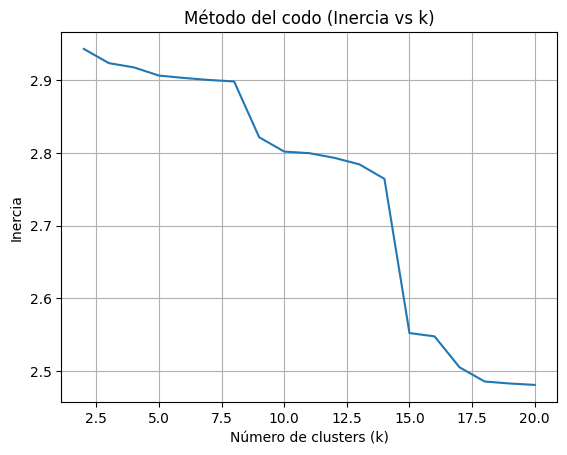

,k,silhouette,consumo_diff,inertia,min_cluster_size,max_cluster_size,balance_ratio
0,2,0.277475,0.276404,2.943164,2,1883,0.001062
1,3,0.165166,0.221016,2.923617,2,1857,0.001077
2,4,0.104214,0.198275,2.917765,2,1850,0.001081
3,5,0.046486,0.225567,2.906499,2,1840,0.001087
4,6,0.011907,0.212636,2.903215,2,1837,0.001089
5,7,-0.003969,0.218924,2.900466,2,1837,0.001089
6,8,-0.010366,0.253309,2.898378,1,1837,0.000544
7,9,-0.005760,0.239898,2.821672,1,1676,0.000597
8,10,-0.014307,0.231845,2.801976,1,1676,0.000597
9,11,-0.020115,0.235351,2.799768,1,1676,0.000597


In [352]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from joblib import Parallel, delayed
import pandas as pd
import numpy as np


def calcular_inercia(X, labels):
    inertia = 0.0
    for cluster in np.unique(labels):
        puntos = X[labels == cluster]
        centroide = puntos.mean(axis=0)
        inertia += ((puntos - centroide) ** 2).sum()
    return inertia


def calcular_distancia_promedio(X, labels):
    total_dist = 0.0
    total_points = len(X)
    
    for cluster in np.unique(labels):
        puntos = X[labels == cluster]
        centroide = puntos.mean(axis=0)
        distancias = np.linalg.norm(puntos - centroide, axis=1)
        total_dist += distancias.sum()
    
    return total_dist / total_points
    
def evaluar_k(k, X, Y_bin, linkage="average"):
    model = AgglomerativeClustering(
        n_clusters=k,
        metric='euclidean',
        linkage=linkage
    )
    
    labels = model.fit_predict(X)
    
    # --- Silhouette ---
    sil = silhouette_score(X, labels)
    
    # --- Inercia (distancia promedio) ---
    avg_dist = calcular_distancia_promedio(X.values, labels)
    
    # --- Consumo ---
    df_clusters = pd.DataFrame({'cluster': labels})
    df_full = df_clusters.join(Y_bin)
    
    consumo = df_full.groupby('cluster')[Y_bin.columns].mean()
    consumo_score = consumo.std().mean()
    
    # =========================
    # 🔥 NUEVA MÉTRICA
    # =========================
    counts = pd.Series(labels).value_counts().sort_index()
    
    min_size = counts.min()
    max_size = counts.max()
    imbalance = min_size / max_size  # entre 0 y 1
    
    return k, sil, consumo_score, avg_dist, min_size, max_size, imbalance
    

resultados = Parallel(n_jobs=-1)(
    delayed(evaluar_k)(k, X, Y_bin) for k in range(2, 21)
)

df_resultados = pd.DataFrame(
    resultados,
    columns=[
        'k',
        'silhouette',
        'consumo_diff',
        'inertia',
        'min_cluster_size',
        'max_cluster_size',
        'balance_ratio'
    ]
)

import matplotlib.pyplot as plt


plt.figure()
plt.plot(df_resultados['k'], df_resultados['inertia'])
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.grid()
plt.title('Método del codo (Inercia vs k)')
plt.show()

df_resultados

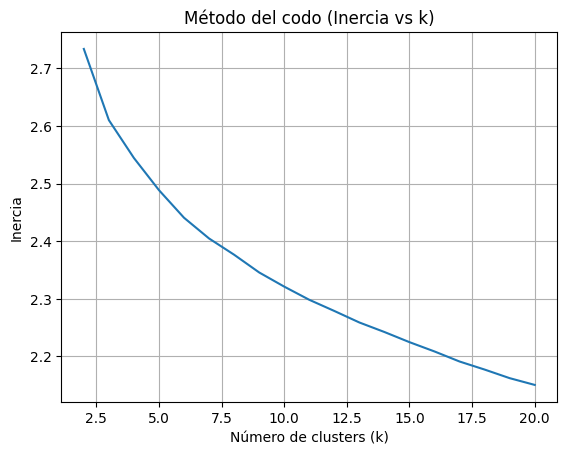

,k,silhouette,consumo_diff,inertia,min_cluster_size,max_cluster_size,balance_ratio
0,2,0.125251,0.145595,2.733814,904,981,0.921509
1,3,0.112309,0.121056,2.610235,319,981,0.325178
2,4,0.075319,0.124080,2.544490,319,585,0.545299
3,5,0.072705,0.113807,2.488679,141,585,0.241026
4,6,0.070407,0.114503,2.440762,141,463,0.304536
5,7,0.060619,0.117238,2.404796,119,405,0.293827
6,8,0.052353,0.119422,2.376610,119,377,0.315650
7,9,0.049089,0.119513,2.345820,96,377,0.254642
8,10,0.045181,0.121478,2.321248,96,377,0.254642
9,11,0.040432,0.125276,2.298380,96,377,0.254642


In [354]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from joblib import Parallel, delayed
import pandas as pd
import numpy as np

def calcular_inercia(X, labels):
    inertia = 0.0
    for cluster in np.unique(labels):
        puntos = X[labels == cluster]
        centroide = puntos.mean(axis=0)
        inertia += ((puntos - centroide) ** 2).sum()
    return inertia


def calcular_distancia_promedio(X, labels):
    total_dist = 0.0
    total_points = len(X)
    
    for cluster in np.unique(labels):
        puntos = X[labels == cluster]
        centroide = puntos.mean(axis=0)
        distancias = np.linalg.norm(puntos - centroide, axis=1)
        total_dist += distancias.sum()
    
    return total_dist / total_points

def evaluar_k(k, X, Y_bin, linkage="ward"):
    model = AgglomerativeClustering(
        n_clusters=k,
        metric='euclidean',
        linkage=linkage
    )
    
    labels = model.fit_predict(X)
    
    # --- Silhouette ---
    sil = silhouette_score(X, labels)
    
    # --- Inercia (distancia promedio) ---
    avg_dist = calcular_distancia_promedio(X.values, labels)
    
    # --- Consumo ---
    df_clusters = pd.DataFrame({'cluster': labels})
    df_full = df_clusters.join(Y_bin)
    
    consumo = df_full.groupby('cluster')[Y_bin.columns].mean()
    consumo_score = consumo.std().mean()
    
    # =========================
    # 🔥 NUEVA MÉTRICA
    # =========================
    counts = pd.Series(labels).value_counts().sort_index()
    
    min_size = counts.min()
    max_size = counts.max()
    imbalance = min_size / max_size  # entre 0 y 1
    
    return k, sil, consumo_score, avg_dist, min_size, max_size, imbalance
    

resultados = Parallel(n_jobs=-1)(
    delayed(evaluar_k)(k, X, Y_bin) for k in range(2, 21)
)

df_resultados = pd.DataFrame(
    resultados,
    columns=[
        'k',
        'silhouette',
        'consumo_diff',
        'inertia',
        'min_cluster_size',
        'max_cluster_size',
        'balance_ratio'
    ]
)

import matplotlib.pyplot as plt


plt.figure()
plt.plot(df_resultados['k'], df_resultados['inertia'])
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.grid()
plt.title('Método del codo (Inercia vs k)')
plt.show()

df_resultados

El método Ward mostró un desempeño significativamente superior frente a average linkage. Mientras que average generó clusters altamente desbalanceados y degenerados (con tamaños mínimos de 1 o 2 observaciones), Ward produjo particiones más compactas, balanceadas y estables, lo que indica una mejor captura de la estructura subyacente de los datos.

Se compararon los métodos de enlace average y Ward dentro del clustering jerárquico aglomerativo. Los resultados evidenciaron que average linkage genera clusters altamente desbalanceados y poco representativos, con tamaños mínimos de uno o dos elementos, lo cual sugiere un efecto de encadenamiento y una mala captura de la estructura de los datos.

Por el contrario, Ward produjo clusters más compactos, balanceados y consistentes, manteniendo valores positivos de silhouette y reduciendo la inercia de forma progresiva.

En cuanto a la selección del número de clusters, se observó que aunque métricas como consumo_diff mejoran con valores altos de k, esto ocurre a costa de una mayor fragmentación. Por tanto, se seleccionó un valor de k entre 4 y 5, ya que ofrece un balance adecuado entre interpretabilidad, cohesión interna y diferenciación entre grupos.

In [372]:
evaluar_k(4, X, Y_bin, "ward")

(4, 0.07531926582004114, 0.12408015788152879, 2.5444897844432055)

In [373]:
evaluar_k(4, X, Y_bin, "ward")

(4, 0.07531926582004114, 0.12408015788152879, 2.5444897844432055)

# Graficas

In [395]:
from scipy.cluster.hierarchy import dendrogram
import numpy as np
import matplotlib.pyplot as plt

def plot_dendrogram(model, truncate_mode=None, p=10):
    
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([
        model.children_,
        model.distances_,
        counts
    ]).astype(float)

    plt.figure(figsize=(12, 10))
    dendrogram(
        linkage_matrix,
        truncate_mode=truncate_mode,  # "level" o None
        p=p
    )
    plt.title("Dendrograma")
    plt.xlabel("Índice de muestras")
    #plt.grid()
    plt.ylabel("Distancia")
    plt.show()

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd

def evaluar_k_con_dendrograma(X, Y_bin, linkage="ward", plot_tree=True):
    
    # modelo completo (árbol)
    model_full = AgglomerativeClustering(
        distance_threshold=0,
        n_clusters=None,
        linkage=linkage,
        compute_distances=True
    )
    
    model_full.fit(X)

    if plot_tree:
        plot_dendrogram(model_full, truncate_mode="level", p=3)

    return model_full

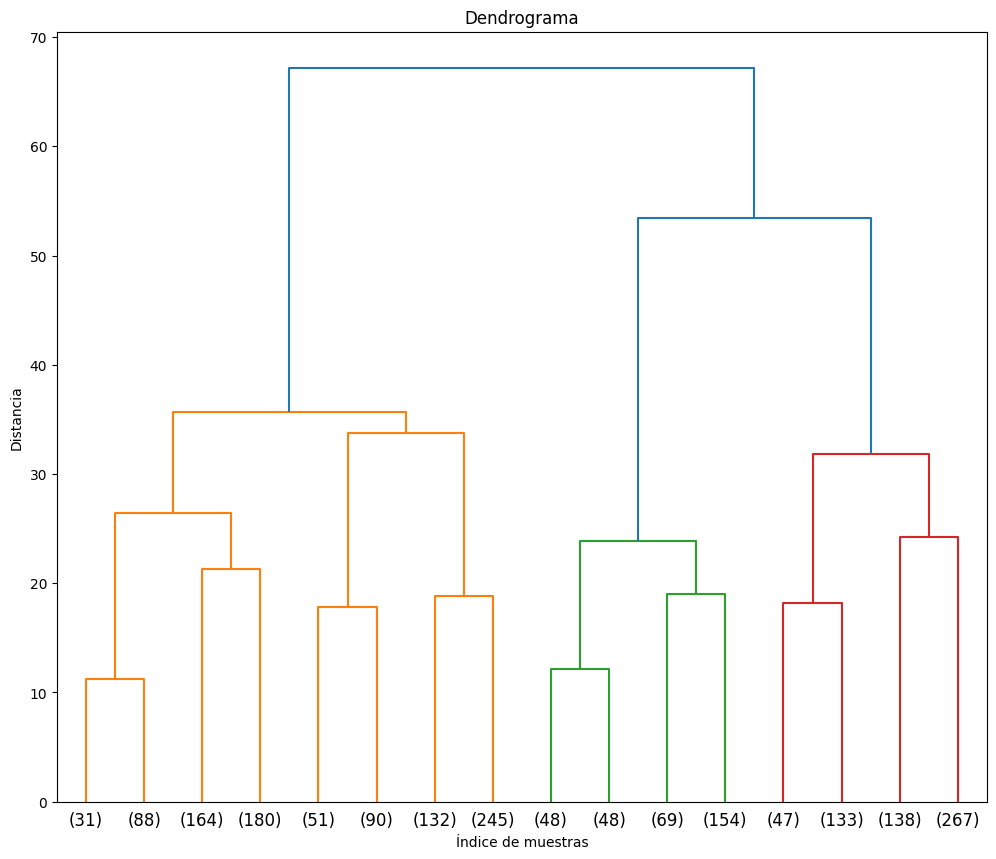

In [396]:
model = evaluar_k_con_dendrograma(X, Y_bin, linkage="ward")
#plot_dendrogram(model, truncate_mode=None, p=7)

In [376]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd

def evaluar_k(k, X, Y_bin, linkage="ward", return_data=False):
    
    model = AgglomerativeClustering(
        n_clusters=k,
        metric='euclidean',
        linkage=linkage
    )
    
    labels = model.fit_predict(X)
    
    # --- Silhouette ---
    sil = silhouette_score(X, labels)
    
    # --- Inercia (distancia promedio) ---
    avg_dist = calcular_distancia_promedio(X.values, labels)
    
    # --- Construcción de DataFrames ---
    df_clusters = pd.DataFrame({'cluster': labels}, index=X.index)
    
    X_clustered = X.join(df_clusters)
    Y_clustered = Y_bin.join(df_clusters)
    
    # --- Consumo ---
    consumo = Y_clustered.groupby('cluster')[Y_bin.columns].mean()
    consumo_score = consumo.std().mean()
    
    if return_data:
        return {
            "k": k,
            "silhouette": sil,
            "consumo_diff": consumo_score,
            "inercia": avg_dist,
            "X_clustered": X_clustered,
            "Y_clustered": Y_clustered
        }
    
    return k, sil, consumo_score, avg_dist

In [377]:
resultado = evaluar_k(4, X, Y_bin, linkage="ward", return_data=True)

X_clustered = resultado["X_clustered"]
Y_clustered = resultado["Y_clustered"]
display(X_clustered)
display(Y_clustered)

,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,impuslive,ss,cluster
0,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,-0.21712,-1.18084,3
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,-0.71126,-0.21575,2
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,-1.37983,0.40148,0
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,-1.37983,-1.18084,3
4,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,-0.21712,-0.21575,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,-1.19430,1.74091,1.88511,0.76096,-1.13788,0.88113,1.92173,2
1881,-0.95197,-0.48246,-0.61113,-0.57009,-0.31685,-0.24649,1.74091,0.58331,0.76096,-1.51840,0.88113,0.76540,1
1882,-0.07854,0.48246,0.45468,-0.57009,-0.31685,1.13281,-1.37639,-1.27553,-1.77200,-1.38502,0.52975,-0.52593,1
1883,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,0.91093,-1.92173,0.29338,-1.62090,-2.57309,1.29221,1.22470,1


,alcohol,amphet,amyl,benzos,caff,cannabis,choc,coke,crack,ecstasy,heroin,ketamine,legalh,lsd,meth,mushrooms,nicotine,semer,vsa,cluster
0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,3
1,1,0,0,0,1,1,1,1,0,1,0,0,0,0,1,0,1,0,0,2
2,1,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,3
4,1,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880,1,0,0,0,1,1,1,0,0,0,0,0,1,1,0,0,0,0,1,2
1881,1,0,0,0,1,1,1,0,0,0,0,0,1,1,1,1,1,0,0,1
1882,1,1,1,1,1,1,1,1,0,1,0,0,0,0,0,0,1,0,0,1
1883,1,0,0,0,1,1,1,0,0,1,0,0,1,1,0,1,1,0,0,1


,alcohol,amphet,amyl,benzos,caff,cannabis,choc,coke,crack,ecstasy,heroin,ketamine,legalh,lsd,meth,mushrooms,nicotine,semer,vsa
cluster,,,,,,,,,,,,,,,,,,,
0,0.905405,0.115830,0.052124,0.208494,0.969112,0.389961,0.972973,0.148649,0.034749,0.156371,0.030888,0.052124,0.135135,0.061776,0.083012,0.086873,0.472973,0.000000,0.019305
1,0.936752,0.427350,0.107692,0.487179,0.972650,0.815385,0.976068,0.367521,0.078632,0.441026,0.138462,0.194872,0.536752,0.350427,0.336752,0.396581,0.764103,0.001709,0.097436
2,0.965517,0.341693,0.097179,0.329154,0.987461,0.786834,0.974922,0.313480,0.043887,0.476489,0.056426,0.184953,0.476489,0.416928,0.203762,0.463950,0.714734,0.006270,0.078370
3,0.915767,0.036717,0.025918,0.079914,0.946004,0.149028,0.980562,0.053996,0.002160,0.056156,0.006479,0.017279,0.060475,0.021598,0.032397,0.019438,0.302376,0.000000,0.006479


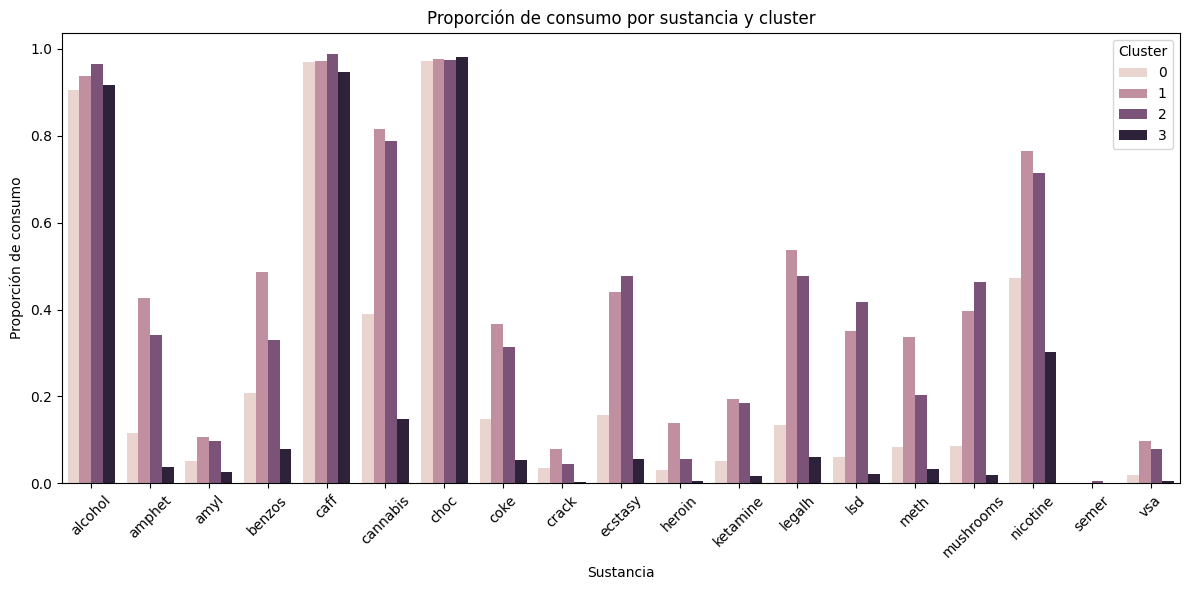

In [382]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_consumo_por_cluster(Y_clustered):
    
    # promedio = proporción de consumo
    consumo_cluster = Y_clustered.groupby('cluster').mean()

    display(consumo_cluster)
    
    # pasar a formato largo (long format)
    consumo_long = consumo_cluster.reset_index().melt(
        id_vars='cluster',
        var_name='sustancia',
        value_name='proporcion'
    )
    
    plt.figure(figsize=(12, 6))
    
    sns.barplot(
        data=consumo_long,
        x='sustancia',
        y='proporcion',
        hue='cluster'
    )
    
    plt.title('Proporción de consumo por sustancia y cluster')
    plt.xlabel('Sustancia')
    plt.ylabel('Proporción de consumo')
    plt.xticks(rotation=45)
    plt.legend(title='Cluster')
    plt.tight_layout()
    
    plt.show()

plot_consumo_por_cluster(Y_clustered)

## Interpretación de clusters basada en prevalencia de consumo

Los valores presentados corresponden al promedio de variables binarias (0/1), por lo que pueden interpretarse como la proporción de individuos dentro de cada cluster que han consumido cada sustancia en un periodo reciente. En este sentido, el análisis permite identificar diferencias en la **prevalencia de consumo**, pero no en la frecuencia o intensidad del mismo.

### Cluster 3: Baja prevalencia de consumo ilegal

Este cluster presenta los niveles más bajos de consumo en la mayoría de las sustancias ilegales:

- Cannabis: 0.149  
- Cocaína: 0.054  
- Éxtasis: 0.056  
- Heroína: 0.006  

El consumo de nicotina (0.302) también es menor en comparación con otros grupos.

En contraste, sustancias legales como alcohol (0.916), cafeína (0.946) y chocolate (0.981) presentan valores altos, consistentes con el resto de los clusters.

**Conclusión:**  
Este grupo se caracteriza por una baja prevalencia de consumo reciente de sustancias ilegales, concentrando su consumo principalmente en sustancias legales.

---

### Cluster 0: Prevalencia intermedia de consumo

Este cluster muestra un aumento en la proporción de consumo de sustancias ilegales respecto al cluster 3:

- Cannabis: 0.390  
- Cocaína: 0.149  
- Éxtasis: 0.156  

El consumo de nicotina (0.473) también se sitúa en un nivel intermedio.

**Conclusión:**  
Este grupo presenta una prevalencia intermedia de consumo reciente de sustancias ilegales, superior al grupo de baja prevalencia, pero sin alcanzar los niveles observados en los clusters de mayor exposición.

---

### Cluster 2: Alta prevalencia selectiva

Este cluster presenta altos niveles de consumo en un conjunto específico de sustancias:

- Cannabis: 0.787  
- Éxtasis: 0.476  
- LSD: 0.417  
- Hongos: 0.464  

Sin embargo, el consumo de sustancias como heroína (0.056) y crack (0.044) se mantiene relativamente bajo.

El consumo de nicotina (0.715) es elevado.

**Conclusión:**  
Este grupo se caracteriza por una alta prevalencia de consumo reciente en sustancias recreativas y psicodélicas, sin extenderse de forma homogénea a todas las drogas.

---

### Cluster 1: Alta prevalencia generalizada

Este cluster presenta niveles elevados de consumo en una amplia variedad de sustancias:

- Cannabis: 0.815  
- Cocaína: 0.368  
- Éxtasis: 0.441  
- Metanfetaminas: 0.337  
- Heroína: 0.138  

El consumo de nicotina (0.764) también es alto.

**Conclusión:**  
Este grupo muestra una alta prevalencia de consumo reciente en múltiples sustancias, incluyendo tanto drogas recreativas como de mayor riesgo.

---

### Conclusión general

El análisis permite identificar una segmentación clara en función de la prevalencia de consumo reciente de sustancias:

- Cluster 3: baja prevalencia  
- Cluster 0: prevalencia intermedia  
- Cluster 2: alta prevalencia selectiva  
- Cluster 1: alta prevalencia generalizada  

Es importante destacar que, debido a la naturaleza binaria de las variables, estos resultados deben interpretarse exclusivamente en términos de presencia o ausencia de consumo reciente, sin inferir frecuencia, intensidad o niveles de dependencia.

In [390]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import math

def plot_mixto_clusters(X_clustered):
    
    # =========================
    # 1. Mapas categóricos
    # =========================
    age_map = {
        -0.95197: "18-24",
        -0.07854: "25-34",
        0.49788: "35-44",
        1.09449: "45-54",
        1.82213: "55-64",
        2.59171: "65+"
    }

    gender_map = {
        0.48246: "Mujer",
        -0.48246: "Hombre"
    }

    education_map = {
        -2.43591: "<16",
        -1.73790: "16",
        -1.43719: "17",
        -1.22751: "18",
        -0.61113: "Sin título",
        -0.05921: "Diploma",
        0.45468: "Universitario",
        1.16365: "Maestría",
        1.98437: "Doctorado"
    }

    country_map = {
        -0.09765: "Australia",
        0.24923: "Canadá",
        -0.46841: "NZ",
        -0.28519: "Otros",
        0.21128: "Irlanda",
        0.96082: "UK",
        -0.57009: "USA"
    }

    ethnicity_map = {
        -0.50212: "Asiático",
        -1.10702: "Negro",
        1.90725: "Negro/Asiático",
        0.12600: "Blanco/Asiático",
        -0.22166: "Blanco/Negro",
        0.11440: "Otros",
        -0.31685: "Blanco"
    }

    df = X_clustered.copy()

    # =========================
    # 2. Recodificar categóricas
    # =========================
    df['age'] = df['age'].map(age_map)
    df['gender'] = df['gender'].map(gender_map)
    df['education'] = df['education'].map(education_map)
    df['country'] = df['country'].map(country_map)
    df['ethnicity'] = df['ethnicity'].map(ethnicity_map)

    # =========================
    # 3. Definir tipos
    # =========================
    categoricas = ['age', 'gender', 'education', 'country', 'ethnicity']
    numericas = [col for col in df.columns if col not in categoricas + ['cluster']]

    # =========================
    # 4. RESÚMENES NUMÉRICOS
    # =========================
    print("\n===== RESUMEN NUMÉRICAS (mean, std) =====")
    resumen_num = df.groupby('cluster')[numericas].agg(['mean', 'std'])
    display(resumen_num)

    # =========================
    # 5. RESÚMENES CATEGÓRICOS
    # =========================
    print("\n===== RESUMEN CATEGÓRICAS (proporciones) =====")
    for col in categoricas:
        print(f"\n--- {col} ---")
        tabla = pd.crosstab(
            df[col],
            df['cluster'],
            normalize='columns'
        )
        display(tabla)

    # =========================
    # 6. Crear grid de gráficos
    # =========================
    features = categoricas + numericas
    n = len(features)
    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(18, 5*rows))
    axes = axes.flatten()

    # =========================
    # 7. Graficar
    # =========================
    for i, feature in enumerate(features):

        ax = axes[i]

        if feature in categoricas:
            sns.countplot(
                data=df,
                x=feature,
                hue='cluster',
                ax=ax
            )
            ax.set_title(f"{feature} (categórica)")
            ax.tick_params(axis='x', rotation=45)

        else:
            sns.boxplot(
                data=df,
                x='cluster',
                y=feature,
                ax=ax
            )
            ax.set_title(f"{feature} (numérica)")

        ax.grid()

    # eliminar espacios vacíos
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


===== RESUMEN NUMÉRICAS (mean, std) =====


nscore              escore              oscore              ascore  \
             mean       std      mean       std      mean       std      mean   
cluster                                                                         
0       -0.089465  0.835342 -0.045189  0.744727 -0.251078  0.823061 -0.008492   
1        0.730004  0.825509 -0.491346  1.013846  0.224102  0.924966 -0.527826   
2       -0.757089  0.829538  0.959996  0.822221  0.857207  0.786991  0.472655   
3       -0.300454  0.881224  0.009286  0.852900 -0.595028  0.885937  0.349759   

                     cscore           impuslive                  ss            
              std      mean       std      mean       std      mean       std  
cluster                                                                        
0        0.850175 -0.026702  0.762922  0.010613  0.812005 -0.076933  0.763374  
1        0.946085 -0.647906  0.945860  0.499299  0.912230  0.446729  0.902456  
2        0.937065  0.326327  0.959090  0.236209  0.825434  0.571685  0.741659  
3        0.939513  0.622097  0.805383 -0.776104  0.705889 -0.885653  0.675274


===== RESUMEN CATEGÓRICAS (proporciones) =====

--- age ---


cluster,0,1,2,3
age,,,,
18-24,0.069498,0.613675,0.608150,0.116631
25-34,0.210425,0.225641,0.266458,0.334773
35-44,0.293436,0.111111,0.068966,0.252700
45-54,0.281853,0.039316,0.053292,0.233261
55-64,0.115830,0.010256,0.003135,0.056156
65+,0.028958,0.000000,0.000000,0.006479



--- gender ---


...

cluster,0,1,2,3
education,,,,
16,0.150579,0.030769,0.006270,0.002160
17,0.017375,0.030769,0.006270,0.002160
18,0.050193,0.083761,0.059561,0.012959
<16,0.040541,0.006838,0.009404,0.000000
Diploma,0.152510,0.117949,0.078370,0.209503
Doctorado,0.061776,0.008547,0.040752,0.084233
Maestría,0.167954,0.056410,0.115987,0.272138
Sin título,0.106178,0.488889,0.423197,0.064795
Universitario,0.252896,0.176068,0.260188,0.352052



--- country ---


cluster,0,1,2,3
country,,,,
Australia,0.036680,0.037607,0.025078,0.010799
Canadá,0.059846,0.056410,0.031348,0.028078
Irlanda,0.009653,0.011966,0.012539,0.008639
NZ,0.000000,0.005128,0.006270,0.000000
Otros,0.048263,0.099145,0.087774,0.015119
UK,0.747104,0.217094,0.369906,0.889849
USA,0.098456,0.572650,0.467085,0.047516



--- ethnicity ---


cluster,0,1,2,3
ethnicity,,,,
Asiático,0.013514,0.008547,0.009404,0.023758
Blanco,0.940154,0.912821,0.884013,0.900648
Blanco/Asiático,0.007722,0.011966,0.012539,0.010799
Blanco/Negro,0.007722,0.010256,0.012539,0.012959
Negro,0.015444,0.008547,0.006270,0.038877
Negro/Asiático,0.000000,0.005128,0.000000,0.000000
Otros,0.015444,0.042735,0.075235,0.012959


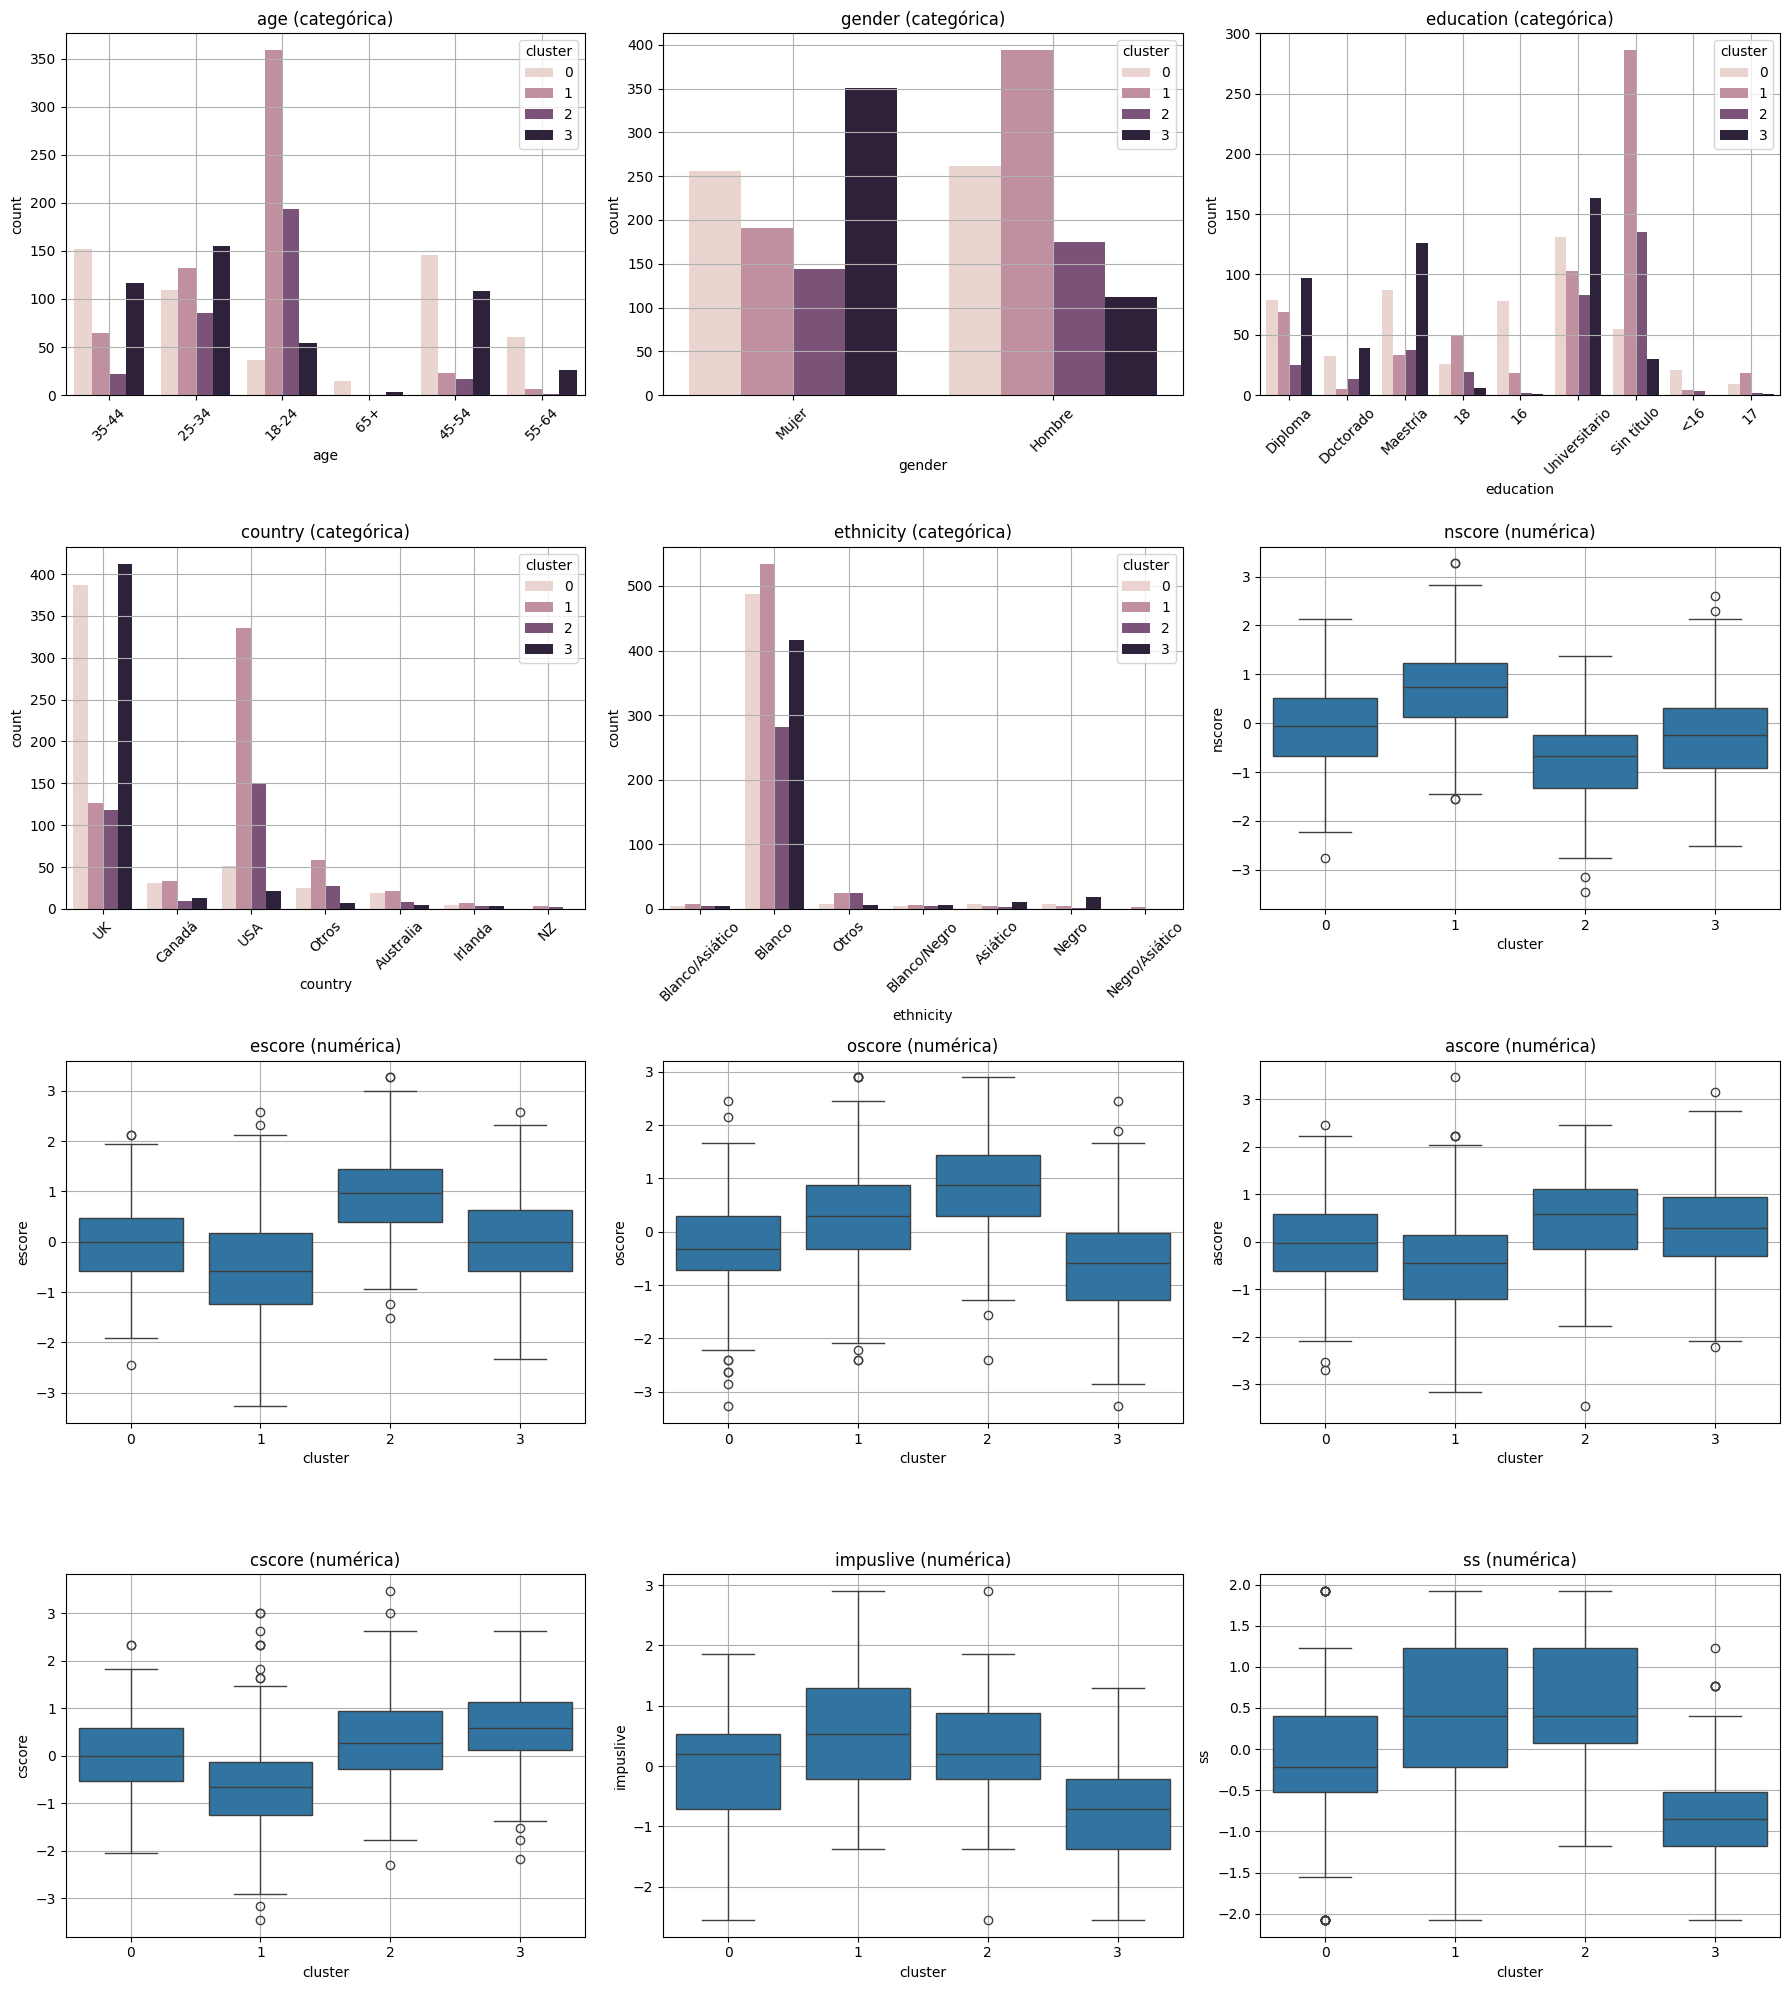

In [391]:
plot_mixto_clusters(X_clustered)

## Interpretación de clusters a partir de variables categóricas

A continuación se describe cada cluster en función de las variables sociodemográficas categóricas, considerando las proporciones observadas dentro de cada grupo.

---

### Cluster 0

Este cluster presenta una distribución etaria más equilibrada, con mayor presencia en rangos de edad entre 35 y 54 años. La participación de individuos jóvenes (18–24) es baja en comparación con otros clusters.

En términos de género, existe un balance entre hombres y mujeres.

El nivel educativo es diverso, con una mayor proporción de individuos con educación universitaria (25%) y posgrados (maestría y doctorado). La categoría “sin título” tiene menor peso relativo frente a otros clusters.

Geográficamente, este cluster está fuertemente concentrado en Reino Unido (~75%), con menor presencia de Estados Unidos (~10%).

La etnicidad está dominada por población blanca, al igual que en el resto de clusters.

**Conclusión:**  
Cluster caracterizado por individuos de mayor edad relativa, con niveles educativos medios-altos y fuerte concentración en Reino Unido.

---

### Cluster 1

Este cluster está claramente dominado por individuos jóvenes (18–24), que representan más del 60% del grupo.

Presenta una mayor proporción de hombres (~67%).

En educación, destaca una alta proporción de individuos sin título (~49%), siendo el rasgo más dominante en esta variable.

A nivel geográfico, está principalmente compuesto por individuos de Estados Unidos (~57%), con menor representación de Reino Unido.

La etnicidad sigue siendo mayoritariamente blanca.

**Conclusión:**  
Cluster compuesto principalmente por población joven, predominantemente masculina, con menor nivel educativo formal y concentrada en Estados Unidos.

---

### Cluster 2

Similar al cluster 1 en edad, con una alta concentración de individuos entre 18 y 34 años, especialmente en el rango 18–24 (~61%).

El género se encuentra más balanceado en comparación con el cluster 1.

En educación, también presenta una alta proporción de individuos sin título (~42%), aunque con mayor presencia de educación universitaria en comparación con el cluster 1.

Geográficamente, muestra una distribución mixta entre Estados Unidos (~47%) y Reino Unido (~37%).

La etnicidad es mayoritariamente blanca, con ligera mayor diversidad que otros clusters.

**Conclusión:**  
Cluster joven, con nivel educativo medio-bajo, y distribución geográfica mixta entre Estados Unidos y Reino Unido.

---

### Cluster 3

Este cluster presenta una distribución etaria más adulta y balanceada, con mayor presencia en los rangos 25–44 años y menor proporción de jóvenes.

Destaca una mayor proporción de mujeres (~76%), siendo el único cluster con predominancia femenina clara.

En educación, presenta los niveles más altos, con mayor proporción de individuos con estudios universitarios (~35%) y de posgrado (~27% maestría).

Geográficamente, está fuertemente concentrado en Reino Unido (~89%).

La etnicidad es similar al resto de clusters, con predominancia de población blanca.

**Conclusión:**  
Cluster compuesto por individuos relativamente más adultos, con mayor nivel educativo, predominancia femenina y fuerte concentración en Reino Unido.

---

## Conclusión general

Los clusters muestran una segmentación clara basada en variables sociodemográficas, especialmente en edad, país y nivel educativo. Se identifican dos grupos jóvenes con menor nivel educativo (clusters 1 y 2) y dos grupos más adultos con mayor nivel educativo (clusters 0 y 3), con una diferenciación adicional en género y ubicación geográfica.


## Interpretación de clusters a partir de variables numéricas (rasgos de personalidad)

Las variables corresponden a escalas estandarizadas (media cercana a 0).  
Valores positivos indican mayor presencia del rasgo, y valores negativos menor presencia relativa.

---

### Cluster 0

- Neuroticismo (Nscore): ligeramente bajo (-0.09)  
- Extraversión (Escore): cercano a la media (-0.04)  
- Apertura (Oscore): baja (-0.25)  
- Amabilidad (Ascore): neutral (-0.01)  
- Responsabilidad (Cscore): ligeramente baja (-0.02)  
- Impulsividad: cercana a la media (0.01)  
- Búsqueda de sensaciones (SS): baja (-0.08)  

**Conclusión:**  
Perfil relativamente estable y cercano al promedio, con baja apertura a nuevas experiencias y baja tendencia a la búsqueda de sensaciones. No presenta rasgos extremos.

---

### Cluster 1

- Neuroticismo: alto (0.73)  
- Extraversión: baja (-0.49)  
- Apertura: moderadamente alta (0.22)  
- Amabilidad: baja (-0.53)  
- Responsabilidad: baja (-0.65)  
- Impulsividad: alta (0.50)  
- Búsqueda de sensaciones: alta (0.45)  

**Conclusión:**  
Perfil con alta inestabilidad emocional (alto neuroticismo), baja regulación (baja responsabilidad), y alta impulsividad. Además, combina baja extraversión con alta búsqueda de sensaciones, lo que sugiere un patrón conductual más reactivo y menos estructurado.

---

### Cluster 2

- Neuroticismo: bajo (-0.76)  
- Extraversión: alta (0.96)  
- Apertura: alta (0.86)  
- Amabilidad: alta (0.47)  
- Responsabilidad: moderadamente alta (0.33)  
- Impulsividad: moderada (0.24)  
- Búsqueda de sensaciones: alta (0.57)  

**Conclusión:**  
Perfil positivo y social: individuos emocionalmente estables, altamente extravertidos y abiertos a nuevas experiencias. Presentan además niveles elevados de búsqueda de sensaciones, combinados con rasgos sociales favorables (amabilidad y responsabilidad relativamente altas).

---

### Cluster 3

- Neuroticismo: bajo (-0.30)  
- Extraversión: cercana a la media (0.01)  
- Apertura: baja (-0.60)  
- Amabilidad: moderadamente alta (0.35)  
- Responsabilidad: alta (0.62)  
- Impulsividad: muy baja (-0.78)  
- Búsqueda de sensaciones: muy baja (-0.89)  

**Conclusión:**  
Perfil altamente controlado: baja impulsividad, baja búsqueda de sensaciones y alta responsabilidad. Además, presenta baja apertura a nuevas experiencias, lo que sugiere un comportamiento más conservador y estructurado.

---

## Conclusión general

Los clusters muestran diferencias claras en rasgos de personalidad:

- Cluster 1: perfil más inestable e impulsivo  
- Cluster 2: perfil social, exploratorio y emocionalmente estable  
- Cluster 3: perfil controlado, conservador y estructurado  
- Cluster 0: perfil intermedio, sin rasgos extremos  

Estas diferencias permiten entender cómo los patrones de comportamiento pueden estar asociados a distintos perfiles psicológicos dentro de la población analizada.


---

## Cluster 0

### Caracterización sociodemográfica

Este cluster presenta una distribución etaria relativamente madura, con mayor presencia en los rangos de 35 a 54 años y baja representación de individuos jóvenes. Existe un balance entre hombres y mujeres.

En términos educativos, se observa un perfil heterogéneo con presencia relevante de educación universitaria (25%) y estudios de posgrado, aunque con menor predominancia de individuos sin título en comparación con otros clusters.

Geográficamente, el cluster está fuertemente concentrado en Reino Unido (~75%), con una participación secundaria de Estados Unidos (~10%). La etnicidad es predominantemente blanca.

### Perfil psicológico (rasgos de personalidad)

El perfil es cercano al promedio en la mayoría de dimensiones. Presenta ligera baja apertura a la experiencia y baja búsqueda de sensaciones, mientras que el resto de rasgos se mantiene en niveles neutros.

### Síntesis

Cluster de individuos de edad media, con nivel educativo medio-alto, fuerte concentración en Reino Unido y un perfil psicológico estable, sin rasgos extremos ni conductas marcadamente impulsivas o exploratorias.

---

## Cluster 1

### Caracterización sociodemográfica

Este cluster está fuertemente dominado por individuos jóvenes (18–24 años), que constituyen más del 60% del grupo. Predomina el género masculino (~67%).

El nivel educativo es bajo en términos relativos, con una alta proporción de individuos sin título (~49%), siendo este el rasgo más distintivo del cluster.

A nivel geográfico, existe una mayor presencia de Estados Unidos (~57%), seguido por Reino Unido. La etnicidad es mayoritariamente blanca.

### Perfil psicológico (rasgos de personalidad)

Se observa un perfil con alta inestabilidad emocional (alto neuroticismo), baja extraversión, baja amabilidad y baja responsabilidad. A esto se suma una alta impulsividad y elevada búsqueda de sensaciones.

### Síntesis

Cluster compuesto principalmente por población joven masculina, con bajo nivel educativo, predominio de Estados Unidos y un perfil psicológico asociado a mayor impulsividad, menor regulación conductual y mayor reactividad emocional.

---

## Cluster 2

### Caracterización sociodemográfica

Este cluster también es predominantemente joven, con fuerte concentración en el rango de 18 a 24 años (~61%), aunque con mayor presencia relativa de individuos entre 25 y 34 años.

El género es más balanceado que en el cluster 1. En educación, se observa una combinación de individuos sin título (~42%) y una mayor proporción de educación universitaria en comparación con el cluster 1.

Geográficamente, presenta una distribución mixta entre Estados Unidos (~47%) y Reino Unido (~37%). La etnicidad es mayoritariamente blanca, con ligera mayor diversidad relativa.

### Perfil psicológico (rasgos de personalidad)

Se caracteriza por bajo neuroticismo, alta extraversión, alta apertura a la experiencia y alta búsqueda de sensaciones. Además, presenta niveles moderados a altos de amabilidad y responsabilidad.

### Síntesis

Cluster joven, socialmente activo y emocionalmente estable, con tendencia exploratoria y mayor apertura a nuevas experiencias, combinado con una distribución geográfica relativamente equilibrada entre Estados Unidos y Reino Unido.

---

## Cluster 3

### Caracterización sociodemográfica

Este cluster presenta una estructura etaria más adulta, con mayor representación en rangos de 25 a 44 años y menor proporción de jóvenes.

Existe una fuerte predominancia femenina (~76%), siendo el único cluster con una asimetría de género marcada.

En educación, concentra los niveles más altos del conjunto, con mayor proporción de educación universitaria (~35%) y posgrado (~27% maestría). Geográficamente, está altamente concentrado en Reino Unido (~89%). La etnicidad es mayoritariamente blanca.

### Perfil psicológico (rasgos de personalidad)

Presenta baja neuroticismo, baja apertura a la experiencia, muy baja impulsividad y muy baja búsqueda de sensaciones. A su vez, destaca por alta responsabilidad y niveles moderados de amabilidad.

### Síntesis

Cluster compuesto por individuos más adultos, altamente concentrado en Reino Unido, con predominancia femenina y un perfil psicológico caracterizado por control conductual, baja impulsividad y tendencia a la estabilidad y estructura.

---

## Conclusión general

Los clusters muestran una segmentación consistente tanto en variables sociodemográficas como psicológicas. Se identifican dos perfiles jóvenes diferenciados: uno asociado a mayor impulsividad y menor regulación (Cluster 1), y otro más social y estable con alta apertura (Cluster 2). Por otro lado, los clusters 0 y 3 corresponden a perfiles más adultos, con mayor nivel educativo y menor variabilidad conductual, destacando el Cluster 3 por su fuerte control conductual y estructura.

La segmentación sugiere una relación consistente entre edad, nivel educativo, país de origen y rasgos de personalidad dentro del espacio latente del modelo de clustering.


In [392]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

def plot_avanzado_clusters(X_clustered):

    df = X_clustered.copy()

    # =========================
    # 1. MAPAS CATEGÓRICOS
    # =========================
    age_map = {
        -0.95197: "18-24",
        -0.07854: "25-34",
        0.49788: "35-44",
        1.09449: "45-54",
        1.82213: "55-64",
        2.59171: "65+"
    }

    gender_map = {
        0.48246: "Mujer",
        -0.48246: "Hombre"
    }

    education_map = {
        -2.43591: "<16",
        -1.73790: "16",
        -1.43719: "17",
        -1.22751: "18",
        -0.61113: "Sin título",
        -0.05921: "Diploma",
        0.45468: "Universitario",
        1.16365: "Maestría",
        1.98437: "Doctorado"
    }

    country_map = {
        -0.09765: "Australia",
        0.24923: "Canadá",
        -0.46841: "NZ",
        -0.28519: "Otros",
        0.21128: "Irlanda",
        0.96082: "UK",
        -0.57009: "USA"
    }

    ethnicity_map = {
        -0.50212: "Asiático",
        -1.10702: "Negro",
        1.90725: "Negro/Asiático",
        0.12600: "Blanco/Asiático",
        -0.22166: "Blanco/Negro",
        0.11440: "Otros",
        -0.31685: "Blanco"
    }

    # =========================
    # 2. RECODIFICAR
    # =========================
    df['age'] = df['age'].map(age_map)
    df['gender'] = df['gender'].map(gender_map)
    df['education'] = df['education'].map(education_map)
    df['country'] = df['country'].map(country_map)
    df['ethnicity'] = df['ethnicity'].map(ethnicity_map)

    categoricas = ['age', 'gender', 'education', 'country', 'ethnicity']
    numericas = [col for col in df.columns if col not in categoricas + ['cluster']]

    clusters = sorted(df['cluster'].unique())

    # ==========================================================
    # 🔹 3. NUMÉRICAS → BOXPLOT POR CLUSTER
    # ==========================================================
    n_clusters = len(clusters)
    fig, axes = plt.subplots(1, n_clusters, figsize=(6*n_clusters, 5), sharey=True)

    if n_clusters == 1:
        axes = [axes]

    for i, cluster in enumerate(clusters):
        data_cluster = df[df['cluster'] == cluster]

        df_melt = data_cluster[numericas].melt(
            var_name='feature',
            value_name='value'
        )

        sns.boxplot(
            data=df_melt,
            x='feature',
            y='value',
            ax=axes[i]
        )

        axes[i].set_title(f'Cluster {cluster}')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].grid()

    plt.suptitle('Distribución de variables numéricas por cluster')
    plt.tight_layout()
    plt.show()

    # ==========================================================
    # 🔹 4. CATEGÓRICAS → SUBPLOTS SEPARADOS POR CLUSTER
    # ==========================================================
    n_features = len(categoricas)
    fig = plt.figure(figsize=(12, 4 * n_features))

    outer_grid = fig.add_gridspec(n_features, 1)

    for i, feature in enumerate(categoricas):
        
        inner_grid = outer_grid[i].subgridspec(1, n_clusters)

        for j, cluster in enumerate(clusters):
            
            ax = fig.add_subplot(inner_grid[j])
            data_cluster = df[df['cluster'] == cluster]

            sns.countplot(
                data=data_cluster,
                x=feature,
                ax=ax
            )

            ax.set_title(f"{feature} | Cluster {cluster}")
            ax.tick_params(axis='x', rotation=45)
            ax.grid()

    plt.suptitle('Distribución de variables categóricas por cluster (separadas)')
    plt.tight_layout()
    plt.show()

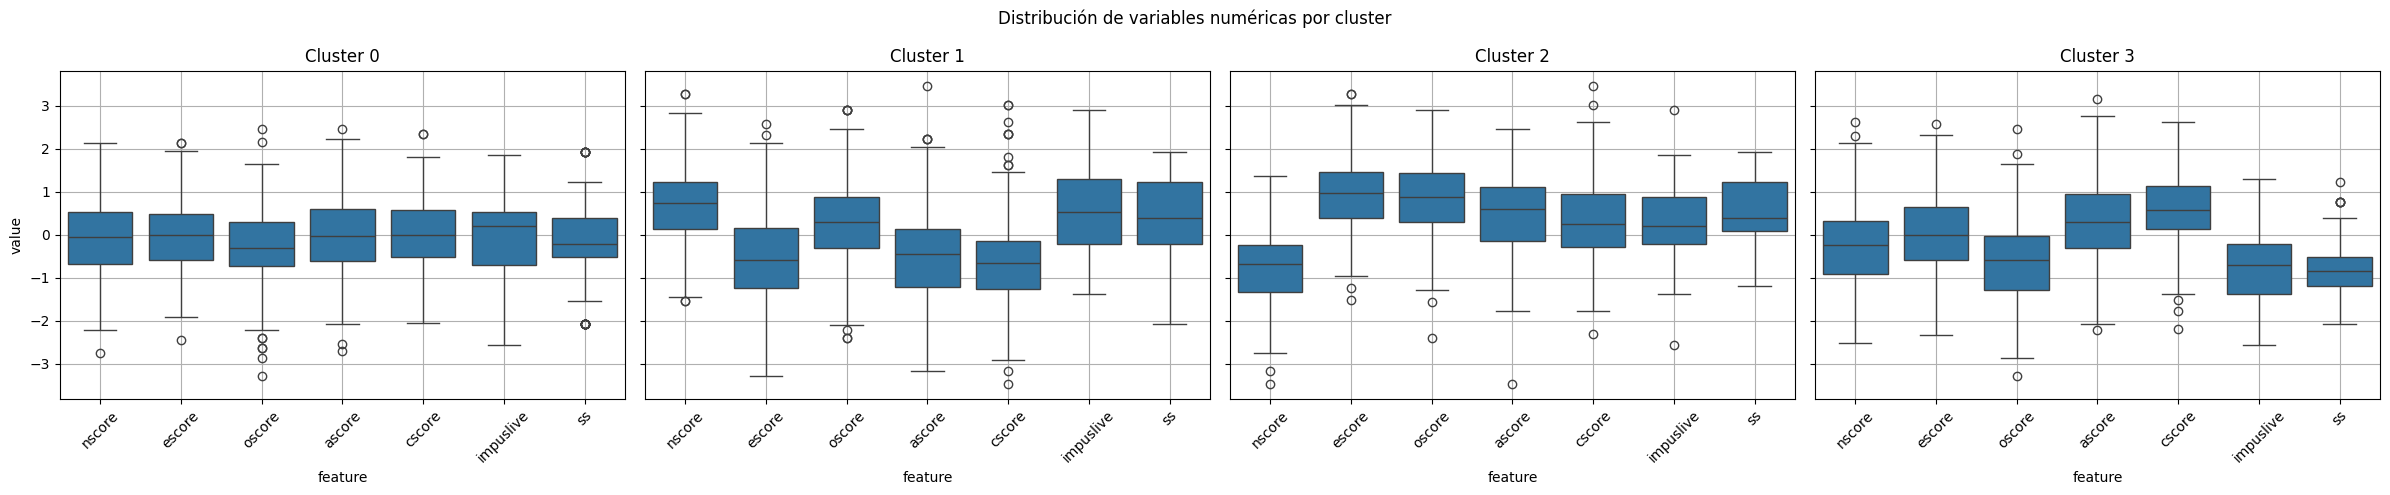

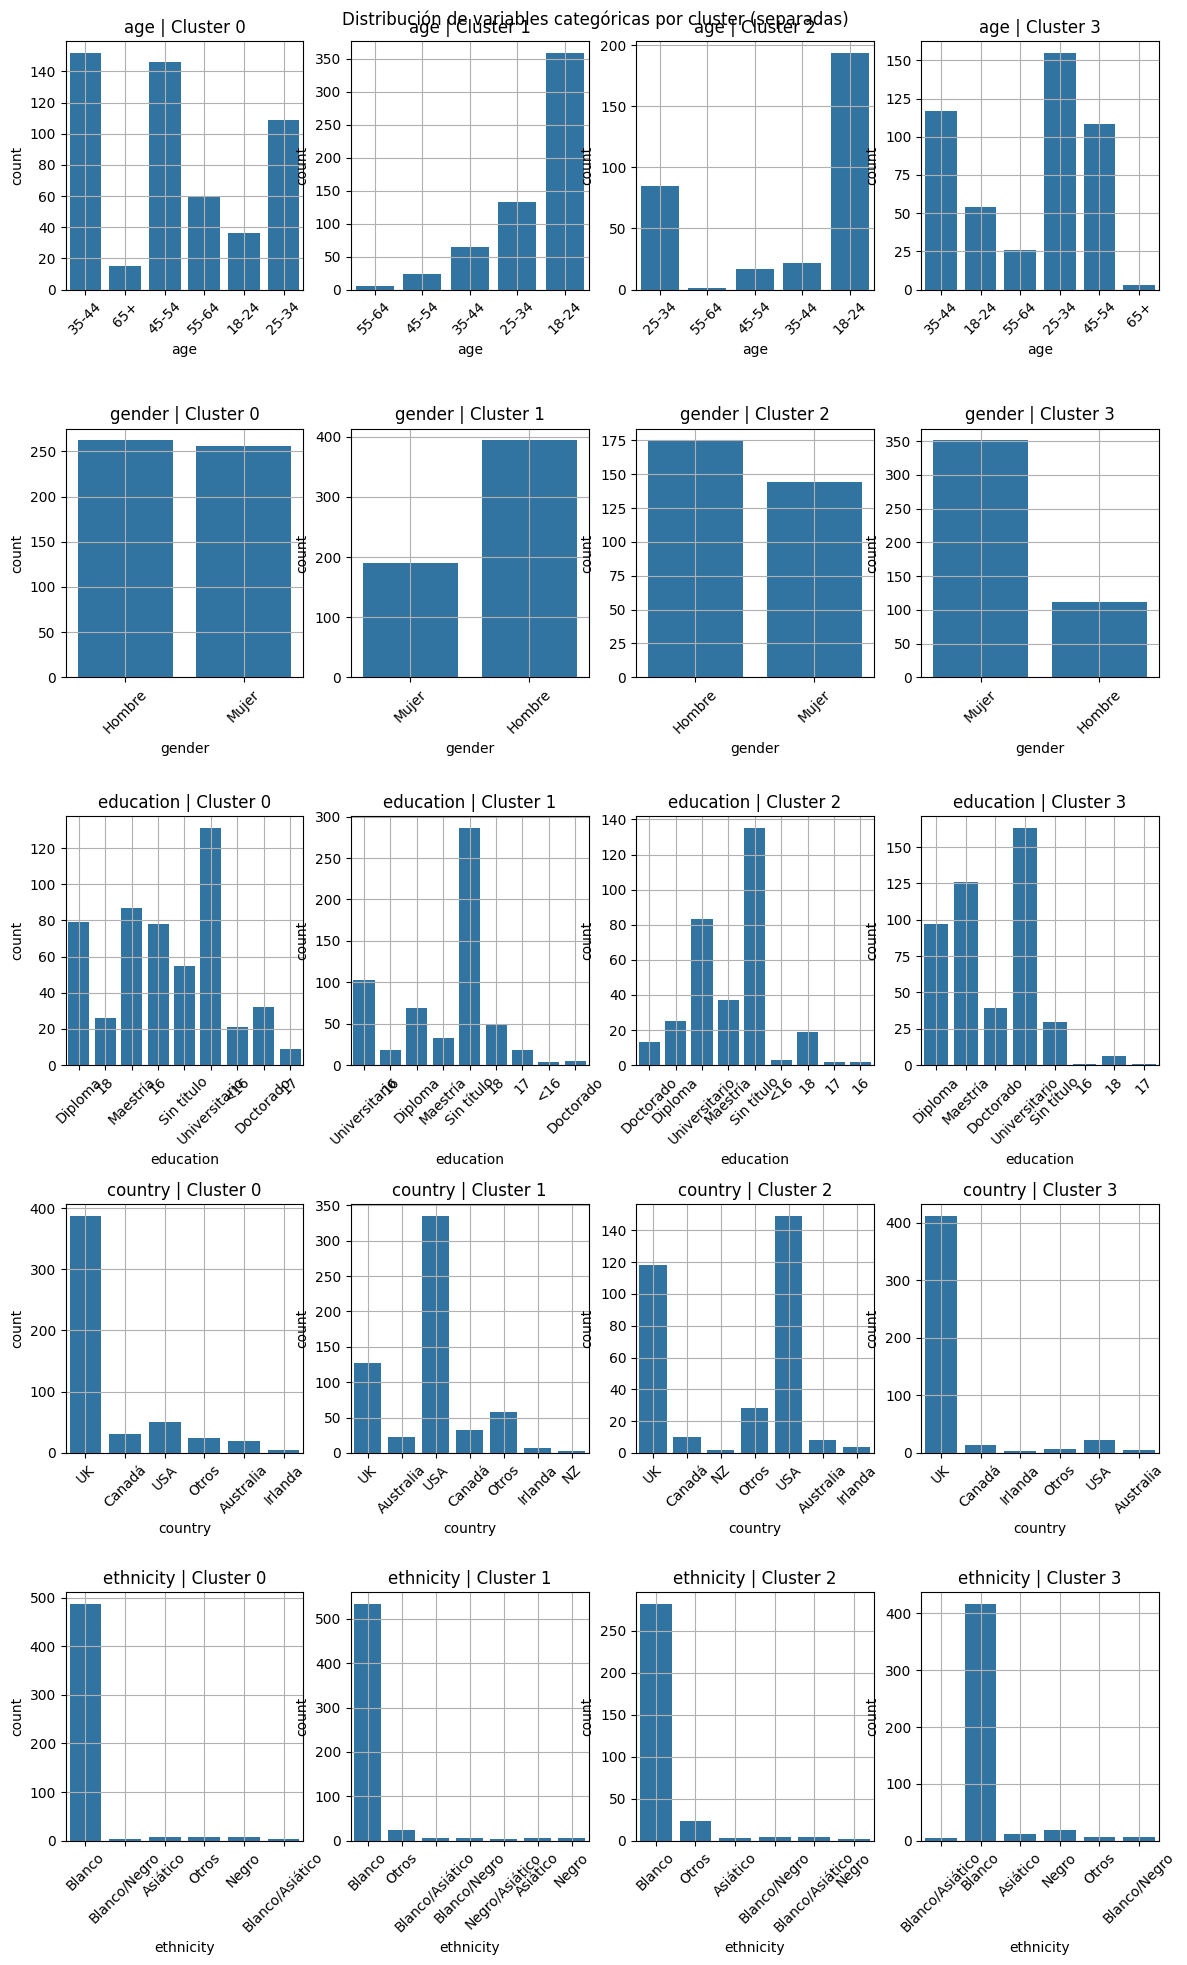

In [393]:
plot_avanzado_clusters(X_clustered)

## Relación entre consumo de sustancias y características por cluster

A continuación se integran los resultados de prevalencia de consumo con las características sociodemográficas y de personalidad previamente descritas. El objetivo es identificar patrones consistentes entre perfiles de individuos y su propensión relativa al consumo reciente de sustancias, sin interpretar frecuencia ni intensidad.

---

## Cluster 0

### Integración de resultados

Este cluster se caracteriza por un perfil de edad media, predominio de individuos del Reino Unido, nivel educativo medio-alto y rasgos de personalidad cercanos al promedio, con ligera baja apertura y baja búsqueda de sensaciones.

En términos de consumo, presenta una prevalencia intermedia de sustancias ilegales, con valores moderados en cannabis, cocaína y éxtasis, y niveles bajos en drogas de mayor riesgo. El consumo de sustancias legales se mantiene alto y consistente con el resto de clusters.

### Interpretación integrada

El perfil sugiere que la estabilidad psicológica relativa y la menor apertura a experiencias nuevas se asocian con una exposición intermedia al consumo reciente de sustancias ilegales. La estructura sociodemográfica de mayor edad relativa y mayor nivel educativo puede estar actuando como factor moderador frente a patrones de consumo más elevados.

---

## Cluster 1

### Integración de resultados

Este cluster está compuesto principalmente por individuos jóvenes, con predominancia masculina, bajo nivel educativo y mayor presencia en Estados Unidos. Psicológicamente, se observa alta inestabilidad emocional, baja responsabilidad, baja amabilidad, alta impulsividad y alta búsqueda de sensaciones.

En cuanto al consumo, presenta la mayor prevalencia generalizada de sustancias, incluyendo cannabis, cocaína, éxtasis, metanfetaminas y heroína, además de consumo elevado de nicotina.

### Interpretación integrada

El perfil combina factores sociodemográficos de riesgo (juventud y menor nivel educativo) con rasgos psicológicos asociados a mayor impulsividad y búsqueda de sensaciones. Esta combinación es consistente con una mayor prevalencia de consumo reciente en múltiples sustancias, incluyendo aquellas de mayor riesgo relativo.

---

## Cluster 2

### Integración de resultados

Este cluster corresponde a una población joven, con distribución de género más equilibrada, nivel educativo intermedio y presencia mixta entre Estados Unidos y Reino Unido. En términos psicológicos, destaca por baja neuroticismo, alta extraversión, alta apertura a la experiencia y alta búsqueda de sensaciones.

En consumo, presenta alta prevalencia selectiva en cannabis, sustancias psicodélicas (LSD, hongos) y éxtasis, mientras que el consumo de drogas de mayor riesgo se mantiene bajo.

### Interpretación integrada

El perfil sugiere una relación entre alta apertura a la experiencia y alta búsqueda de sensaciones con una mayor inclinación hacia sustancias recreativas y psicodélicas. A diferencia del cluster 1, el consumo se concentra en un subconjunto específico de sustancias, lo que sugiere un patrón más exploratorio que compulsivo o generalizado.

---

## Cluster 3

### Integración de resultados

Este cluster está compuesto por individuos de mayor edad relativa, predominancia femenina, alto nivel educativo y fuerte concentración en Reino Unido. Psicológicamente, presenta alta responsabilidad, baja impulsividad, baja apertura a la experiencia y baja búsqueda de sensaciones.

En consumo, presenta la menor prevalencia de sustancias ilegales, con valores bajos en cannabis, cocaína, éxtasis y prácticamente nulos en drogas de mayor riesgo.

### Interpretación integrada

El perfil combina alta responsabilidad, baja impulsividad y baja búsqueda de sensaciones con una menor presencia de consumo reciente de sustancias ilegales. La estructura sociodemográfica más estable y el perfil psicológico conservador se alinean con un patrón de baja exposición general al consumo.

---

## Conclusión general

En conjunto, los resultados evidencian que el consumo de sustancias no se distribuye de manera aleatoria dentro de la población analizada, sino que presenta una estructura consistente asociada a características sociodemográficas. La edad aparece como uno de los factores más relevantes en la segmentación observada, diferenciando grupos jóvenes con mayor exposición al consumo reciente frente a grupos de mayor edad con menor prevalencia. De forma complementaria, el nivel educativo y el país de residencia también muestran patrones diferenciados, donde contextos con menor nivel educativo relativo y mayor concentración en población joven tienden a asociarse con mayores niveles de consumo, mientras que perfiles con mayor formación educativa y mayor edad relativa se relacionan con menor exposición.

Desde la perspectiva de la personalidad, los resultados sugieren una asociación clara entre ciertos rasgos psicológicos y la propensión al consumo de sustancias. En particular, la impulsividad y la búsqueda de sensaciones emergen como dimensiones clave, asociadas a una mayor prevalencia de consumo, especialmente cuando coexisten con baja responsabilidad y mayor inestabilidad emocional. Por otro lado, perfiles con mayor autocontrol, baja impulsividad y menor apertura a la experiencia tienden a concentrar niveles más bajos de consumo reciente, lo que sugiere un rol protector de estos rasgos frente a la experimentación o mantenimiento del consumo.

Finalmente, la interacción entre variables sociodemográficas y de personalidad permite identificar perfiles diferenciados de riesgo. Los clusters con mayor consumo combinan factores como juventud, menor nivel educativo y rasgos impulsivos o exploratorios, mientras que los clusters con menor consumo se asocian a mayor edad, mayor estabilidad conductual y mayor responsabilidad. En este sentido, el consumo de sustancias parece estar mejor explicado por la combinación de factores estructurales y psicológicos que por variables aisladas, lo que refuerza la utilidad del enfoque de clustering para identificar patrones complejos de comportamiento dentro de la población estudiada.


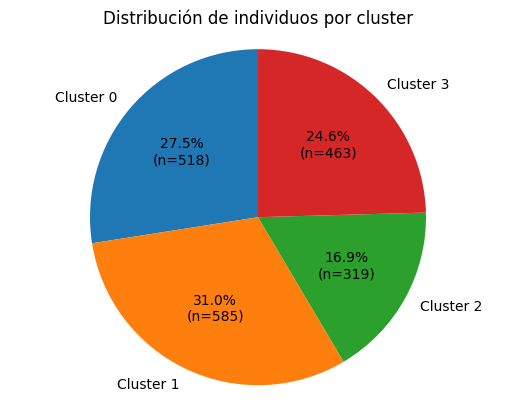

In [394]:
import matplotlib.pyplot as plt

def plot_pie_clusters(X_clustered):
    
    conteo = X_clustered['cluster'].value_counts().sort_index()
    total = conteo.sum()
    
    def formato(pct):
        count = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n(n={count})'
    
    plt.figure()
    plt.pie(
        conteo,
        labels=[f'Cluster {i}' for i in conteo.index],
        autopct=formato,
        startangle=90
    )
    
    plt.title('Distribución de individuos por cluster')
    plt.axis('equal')
    
    plt.show()
plot_pie_clusters(X_clustered)